In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [2]:
import model_train
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
import os
import sys
sys.setrecursionlimit(50000)
import time
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data
torch.backends.cudnn.benchmark = True
torch.set_default_tensor_type('torch.cuda.FloatTensor')
# from tensorboardX import SummaryWriter
torch.nn.Module.dump_patches = True

import numpy as np
import pandas as pd
from rdkit import Chem
from AttentiveFP.code.AttentiveFP import Fingerprint, Fingerprint_viz, Fingerprint_conc, save_smiles_dicts, get_smiles_dicts, get_smiles_array, \
    moltosvg_highlight

from tqdm import tqdm

# Preprocess

In [25]:
with open("../Data/Iteration_Data/Active_Energy_for_AttFP.pickle", 'rb') as f:
    data = pickle.load(f)

In [6]:
mol_dir = 'G:/work/Secondary_Selection/Diene_Ene_Smiles/mol'

In [9]:
raw_filename = "../Data/Iteration_Data/Active_Energy.csv"
all_smiles = []
df = pd.read_csv(raw_filename)
for row_id, row in tqdm(df.iterrows()):
    diene_id = int(row['Diene_Index'])
    ene_id = int(row['Ene_Index'])
    structure_id = int(row['Structure_id'])
    conf_id = int(row['conf_id'])

    diene_mol = Chem.MolFromMolFile(mol_dir + f"/smilesid_{diene_id:05}.mol", removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx() + 1) for atom in diene_mol.GetAtoms()]
    Chem.SanitizeMol(diene_mol)
    Chem.AssignStereochemistryFrom3D(diene_mol)
    diene_smiles = Chem.MolToSmiles(diene_mol)

    ene_mol = Chem.MolFromMolFile(mol_dir + f"/smilesid_{ene_id:05}.mol", removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx() + 1 + diene_mol.GetNumAtoms()) for atom in ene_mol.GetAtoms()]
    Chem.SanitizeMol(ene_mol)
    Chem.AssignStereochemistryFrom3D(ene_mol)
    ene_smiles = Chem.MolToSmiles(ene_mol)

    mol_file = 'G:\work\Secondary_Selection\ZINC_1\mol' + f'/{diene_id:05}_{ene_id:05}_{structure_id:05}.mol'
    product_mol = Chem.MolFromMolFile(mol_file, removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx() + 1) for atom in product_mol.GetAtoms()]
    Chem.SanitizeMol(product_mol)
    Chem.AssignStereochemistryFrom3D(product_mol)
    product_smiles = Chem.MolToSmiles(product_mol)

    all_smiles.append(diene_smiles + "." + ene_smiles + "." + product_smiles)
df['smiles'] = all_smiles
df.to_csv("../Data/Iteration_Data/Active_Energy_for_AttFP.csv", index=False)

[21:51:22] Warning: molecule is tagged as 3D, but all Z coords are zero
[21:51:22] Warning: molecule is tagged as 3D, but all Z coords are zero
[21:51:32] Warning: molecule is tagged as 3D, but all Z coords are zero
[21:51:32] Warning: molecule is tagged as 3D, but all Z coords are zero
[21:51:32] Warning: molecule is tagged as 3D, but all Z coords are zero
[21:51:32] Warning: molecule is tagged as 3D, but all Z coords are zero
[21:51:36] Conflicting single bond directions around double bond at index 0.
[21:51:36]   BondStereo set to STEREONONE and single bond directions set to NONE.
[21:51:36] Conflicting single bond directions around double bond at index 0.
[21:51:36]   BondStereo set to STEREONONE and single bond directions set to NONE.
[21:51:36] Conflicting single bond directions around double bond at index 0.
[21:51:36]   BondStereo set to STEREONONE and single bond directions set to NONE.
[21:51:36] Conflicting single bond directions around double bond at index 0.
[21:51:36]   B

In [10]:
def train(model, dataset, optimizer, loss_function, X=[]):
    model.train()
    np.random.seed(epoch)
    valList = np.arange(0, dataset.shape[0])
    # shuffle them
    np.random.shuffle(valList)
    batch_list = []
    for i in range(0, dataset.shape[0], batch_size):
        batch = valList[i:i + batch_size]
        batch_list.append(batch)

    for counter, batch in enumerate(batch_list):
        batch_df = dataset.loc[batch, :]
        smiles_list = batch_df.cano_smiles.values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(smiles_list,
                                                                                                     feature_dicts)
        if len(X) != 0:
            batch_X = X[batch]
            atoms_prediction, mol_prediction = model(torch.Tensor(x_atom), torch.Tensor(x_bonds),
                                                 torch.cuda.LongTensor(x_atom_index),
                                                 torch.cuda.LongTensor(x_bond_index), torch.Tensor(x_mask), torch.Tensor(batch_X))
        else:
            atoms_prediction, mol_prediction = model(torch.Tensor(x_atom), torch.Tensor(x_bonds),
                                                 torch.cuda.LongTensor(x_atom_index),
                                                 torch.cuda.LongTensor(x_bond_index), torch.Tensor(x_mask))

        optimizer.zero_grad()
        loss = 0.0
        for i, task in enumerate(tasks):
            y_pred = mol_prediction[:, i]
            y_val = batch_df[task + "_normalized"].values
            loss += loss_function(y_pred, torch.Tensor(y_val).squeeze()) * ratio_list[i] ** 2
        loss.backward()
        optimizer.step()

In [11]:
def eval(model, dataset, X=[], return_value=False):
    model.eval()
    eval_MAE_list = {}
    eval_MSE_list = {}
    y_val_list = {}
    y_pred_list = {}
    for i, task in enumerate(tasks):
        y_pred_list[task] = np.array([])
        y_val_list[task] = np.array([])
        eval_MAE_list[task] = np.array([])
        eval_MSE_list[task] = np.array([])

    valList = np.arange(0, dataset.shape[0])
    batch_list = []
    for i in range(0, dataset.shape[0], batch_size):
        batch = valList[i:i + batch_size]
        batch_list.append(batch)
    for counter, batch in enumerate(batch_list):
        batch_df = dataset.loc[batch, :]
        smiles_list = batch_df.cano_smiles.values

        batch_df = dataset.loc[batch, :]
        smiles_list = batch_df.cano_smiles.values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(smiles_list,
                                                                                                     feature_dicts)
        
        if len(X) != 0:
            batch_X = X[batch]
            atoms_prediction, mol_prediction = model(torch.Tensor(x_atom), torch.Tensor(x_bonds),
                                                 torch.cuda.LongTensor(x_atom_index),
                                                 torch.cuda.LongTensor(x_bond_index), torch.Tensor(x_mask), torch.Tensor(batch_X))
        else:
            atoms_prediction, mol_prediction = model(torch.Tensor(x_atom), torch.Tensor(x_bonds),
                                                 torch.cuda.LongTensor(x_atom_index),
                                                 torch.cuda.LongTensor(x_bond_index), torch.Tensor(x_mask))
        for i, task in enumerate(tasks):
            y_pred = mol_prediction[:, i]
            y_val = batch_df[task + "_normalized"].values

            MAE = F.l1_loss(y_pred, torch.Tensor(y_val).squeeze(), reduction='none')
            MSE = F.mse_loss(y_pred, torch.Tensor(y_val).squeeze(), reduction='none')
            y_pred_list[task] = np.concatenate([y_pred_list[task], y_pred.cpu().detach().numpy()])
            y_val_list[task] = np.concatenate([y_val_list[task], y_val])
            eval_MAE_list[task] = np.concatenate([eval_MAE_list[task], MAE.cpu().detach().numpy()])
            #MAE.data.squeeze().cpu().numpy()
            eval_MSE_list[task] = np.concatenate([eval_MSE_list[task], MSE.cpu().detach().numpy()])
            #MSE.data.squeeze().cpu().numpy()

    eval_MAE_normalized = np.array([eval_MAE_list[task].mean() for i, task in enumerate(tasks)])
    eval_MAE = np.multiply(eval_MAE_normalized, np.array(std_list))
    eval_MSE_normalized = np.array([eval_MSE_list[task].mean() for i, task in enumerate(tasks)])
    eval_MSE = np.multiply(eval_MSE_normalized, np.array(std_list))
    y_pred_list_normalized = np.array([y_pred_list[task] for i, task in enumerate(tasks)])
    y_val_list_normalized = np.array([y_val_list[task] for i, task in enumerate(tasks)])
    y_pred_list = y_pred_list_normalized * np.array(std_list).reshape(-1, 1) + np.array(mean_list).reshape(-1, 1)
    y_val_list = y_val_list_normalized * np.array(std_list).reshape(-1, 1) + np.array(mean_list).reshape(-1, 1)
    r2 = [r2_score(y_val_list[each], y_pred_list[each]) for each in range(len(tasks))]
    if return_value:
        return y_val_list, y_pred_list
    return eval_MAE_normalized, eval_MAE, eval_MSE_normalized, eval_MSE, r2

In [10]:
task_name = 'DI'
tasks = [
    "Diene_Distort", 
    "Ene_Distort", 
    "Interaction", 
    "deltaGa(Solvent)"
]
raw_filename = "../Data/Iteration_Data/Active_Energy_for_AttFP.csv"
feature_filename = raw_filename.replace('.csv', '.pickle')
filename = raw_filename.replace('.csv', '')
prefix_filename = raw_filename.split('/')[-1].replace('.csv', '')
smiles_tasks_df = pd.read_csv(raw_filename)

smilesList = smiles_tasks_df.smiles.values
print("number of all smiles: ", len(smilesList))
atom_num_dist = []
remained_smiles = []
canonical_smiles_list = []
for smiles in tqdm(smilesList):
    try:
        mol = Chem.MolFromSmiles(smiles)
        atom_num_dist.append(len(mol.GetAtoms()))
        remained_smiles.append(smiles)
        canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
    except:
        print(smiles)
        pass

print("number of successfully processed smiles: ", len(remained_smiles))
smiles_tasks_df = smiles_tasks_df[smiles_tasks_df["smiles"].isin(remained_smiles)]
smiles_tasks_df['cano_smiles'] = canonical_smiles_list

random_seed = 0
start_time = str(time.ctime()).replace(':', '-').replace(' ', '_')

per_task_output_units_num = 1  # for regression model
output_units_num = len(tasks) * per_task_output_units_num

if os.path.isfile(feature_filename):
    feature_dicts = pickle.load(open(feature_filename, "rb"))
else:
    feature_dicts = save_smiles_dicts(smilesList, filename)

remained_df = smiles_tasks_df[smiles_tasks_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]
uncovered_df = smiles_tasks_df.drop(remained_df.index)

np.random.seed(random_seed)
all_nums = np.arange(len(remained_df))
np.random.shuffle(all_nums)
train_ids = all_nums[:int(0.8 * len(remained_df))]
test_ids = all_nums[int(0.8 * len(remained_df)): int(0.9 * len(remained_df))]
valid_ids = all_nums[int(0.9 * len(remained_df)):]
# np.random.seed(random_seed)
# diene_indexs = np.sort(np.unique(remained_df['Diene_Index'].to_numpy()))
# ene_indexs = np.sort(np.unique(remained_df['Ene_Index'].to_numpy()))
# np.random.shuffle(diene_indexs)
# np.random.shuffle(ene_indexs)
# removed_dienes = diene_indexs[:len(diene_indexs) // 5]
# removed_enes = ene_indexs[:len(ene_indexs) // 5]
# train_ids = [row_id for row_id, row in remained_df.iterrows() if row["Diene_Index"] not in removed_dienes and row["Ene_Index"] not in removed_enes]
# valid_ids = [row_id for row_id, row in remained_df.iterrows() if row["Diene_Index"] in removed_dienes and row["Ene_Index"] in removed_enes]

train_df = remained_df.iloc[train_ids]
test_df = remained_df.iloc[test_ids]
valid_df = remained_df.iloc[valid_ids]
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

training_data = pd.concat([train_df, valid_df])
# get the stats of the seen dataset (the training data)
# which will be used to noramlize the dataset.
columns = ['Task', 'Mean', 'Standard deviation', 'Mean absolute deviation', 'ratio']
mean_list = []
std_list = []
mad_list = []
ratio_list = []
for task in tasks:
    mean = training_data[task].mean()
    mean_list.append(mean)
    std = training_data[task].std()
    std_list.append(std)
    mad = abs(training_data[task] - training_data[task].mean()).mean()
    mad_list.append(mad)
    ratio_list.append(std / mad)
    train_df[task + '_normalized'] = (train_df[task] - mean) / std
    valid_df[task + '_normalized'] = (valid_df[task] - mean) / std
    test_df[task + '_normalized'] = (test_df[task] - mean) / std



number of all smiles:  8273


100%|██████████| 8273/8273 [00:06<00:00, 1359.68it/s]


number of successfully processed smiles:  8273


In [31]:
att_csv_file_dir = "../Data/Iteration_Data/"
train_df.to_csv(CSV_FILE_DIR + "/" + "train.csv", index=False)
valid_df.to_csv(CSV_FILE_DIR + "/" + "valid.csv", index=False)
test_df.to_csv(CSV_FILE_DIR + "/" + "test.csv", index=False)

In [11]:
def OOD_train_valid_test(data):
    np.random.seed(0)
    diene_indexs = np.sort(np.unique(data['Diene_Index'].to_numpy()))
    ene_indexs = np.sort(np.unique(data['Ene_Index'].to_numpy()))
    np.random.shuffle(diene_indexs)
    np.random.shuffle(ene_indexs)
    train_dienes = diene_indexs[:int(len(diene_indexs) * 0.6) ]
    train_enes = ene_indexs[:int(len(ene_indexs) * 0.6)]
    valid_dienes = diene_indexs[int(len(diene_indexs) * 0.6) : int(len(diene_indexs) * 0.8)]
    valid_enes = ene_indexs[int(len(ene_indexs) * 0.6) : int(len(ene_indexs) * 0.8)]
    test_dienes = diene_indexs[int(len(diene_indexs) * 0.8): ]
    test_enes = ene_indexs[int(len(ene_indexs) * 0.8): ]
    train_ids = [row_id for row_id, row in data.iterrows() if row["Diene_Index"] in train_dienes and row["Ene_Index"] in train_enes]
    valid_ids = [row_id for row_id, row in data.iterrows() if row["Diene_Index"] in valid_dienes and row["Ene_Index"] in valid_enes]
    test_ids = [row_id for row_id, row in data.iterrows() if row["Diene_Index"] in test_dienes and row["Ene_Index"] in test_enes]
    print("Train: ", len(train_ids), "Valid: ", len(valid_ids), "Test:",len(test_ids))
    return train_ids, valid_ids, test_ids

In [12]:
# OOD
data_Ea = pd.read_csv(r"../Data/Iteration_Data/Active_Energy_for_AttFP.csv")
train_ids, valid_ids, test_ids = OOD_train_valid_test(data_Ea)
train_df = data_Ea.iloc[train_ids]
test_df = data_Ea.iloc[test_ids]
valid_df = data_Ea.iloc[valid_ids]
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Train:  3524 Valid:  264 Test: 164


In [13]:
CSV_FILE_DIR= r"../Data/Iteration_Data"
QM_MAP = CSV_FILE_DIR + "/" + "all_property_detailSterimol_witharea.pkl"
X_train, _ = model_train.read_df(train_df, QM_MAP)
X_test, _ = model_train.read_df(test_df, QM_MAP)
X_valid, _ = model_train.read_df(valid_df, QM_MAP)

100%|██████████| 264/264 [00:00<00:00, 2167.55it/s]


In [14]:
from catboost import CatBoostRegressor
all_test_trues = []
all_test_preds = []
for task in tasks:
    model = CatBoostRegressor(task_type="CPU", iterations=10000, learning_rate=0.1, depth=6, verbose=0)
    model.fit(X_train, train_df[task])
    a = model.predict(X_valid)
    r2, mae, mse = model_train.r2_score(valid_df[task], a), model_train.mean_absolute_error(valid_df[task], a), model_train.mean_squared_error(valid_df[task], a)
    print(f"task:{task}, Valid_R2:{r2:.4f} Valid_MAE:{mae: .4f} Valid_MSE:{mse: .4f}")
    a = model.predict(X_test)
    r2, mae, mse = model_train.r2_score(test_df[task], a), model_train.mean_absolute_error(test_df[task], a), model_train.mean_squared_error(test_df[task], a)
    print(f"task:{task}, Test_R2:{r2:.4f} Test_MAE:{mae: .4f} Test_MSE:{mse: .4f}")
    all_test_trues.append(test_df[task])
    all_test_preds.append(a)

task:Diene_Distort, Valid_R2:0.4136 Valid_MAE: 2.4536 Valid_MSE: 10.6082
task:Diene_Distort, Test_R2:0.2581 Test_MAE: 3.4442 Test_MSE: 19.9839
task:Ene_Distort, Valid_R2:0.5028 Valid_MAE: 2.1233 Valid_MSE: 7.2275
task:Ene_Distort, Test_R2:0.5404 Test_MAE: 2.2059 Test_MSE: 7.2867
task:Interaction, Valid_R2:0.6136 Valid_MAE: 2.4454 Valid_MSE: 11.0363
task:Interaction, Test_R2:0.4395 Test_MAE: 2.9035 Test_MSE: 16.3471
task:deltaGa(Solvent), Valid_R2:0.4232 Valid_MAE: 3.9143 Valid_MSE: 23.0642
task:deltaGa(Solvent), Test_R2:0.5063 Test_MAE: 3.2632 Test_MSE: 16.8265


task:Diene_Distort, Valid_R2:0.9325 Valid_MAE: 1.0911 Valid_MSE: 2.4721
task:Diene_Distort, Test_R2:0.9340 Test_MAE: 1.0966 Test_MSE: 2.4171
task:Ene_Distort, Valid_R2:0.8140 Valid_MAE: 1.1553 Valid_MSE: 2.7452
task:Ene_Distort, Test_R2:0.8047 Test_MAE: 1.1498 Test_MSE: 2.8166
task:Interaction, Valid_R2:0.8111 Valid_MAE: 1.4774 Valid_MSE: 4.5267
task:Interaction, Test_R2:0.7573 Test_MAE: 1.5992 Test_MSE: 5.3868
task:deltaGa(Solvent), Valid_R2:0.9161 Valid_MAE: 1.6198 Valid_MSE: 5.2601
task:deltaGa(Solvent), Test_R2:0.8983 Test_MAE: 1.6829 Test_MSE: 6.1295

In [35]:
all_test_trues.shape

(3308,)

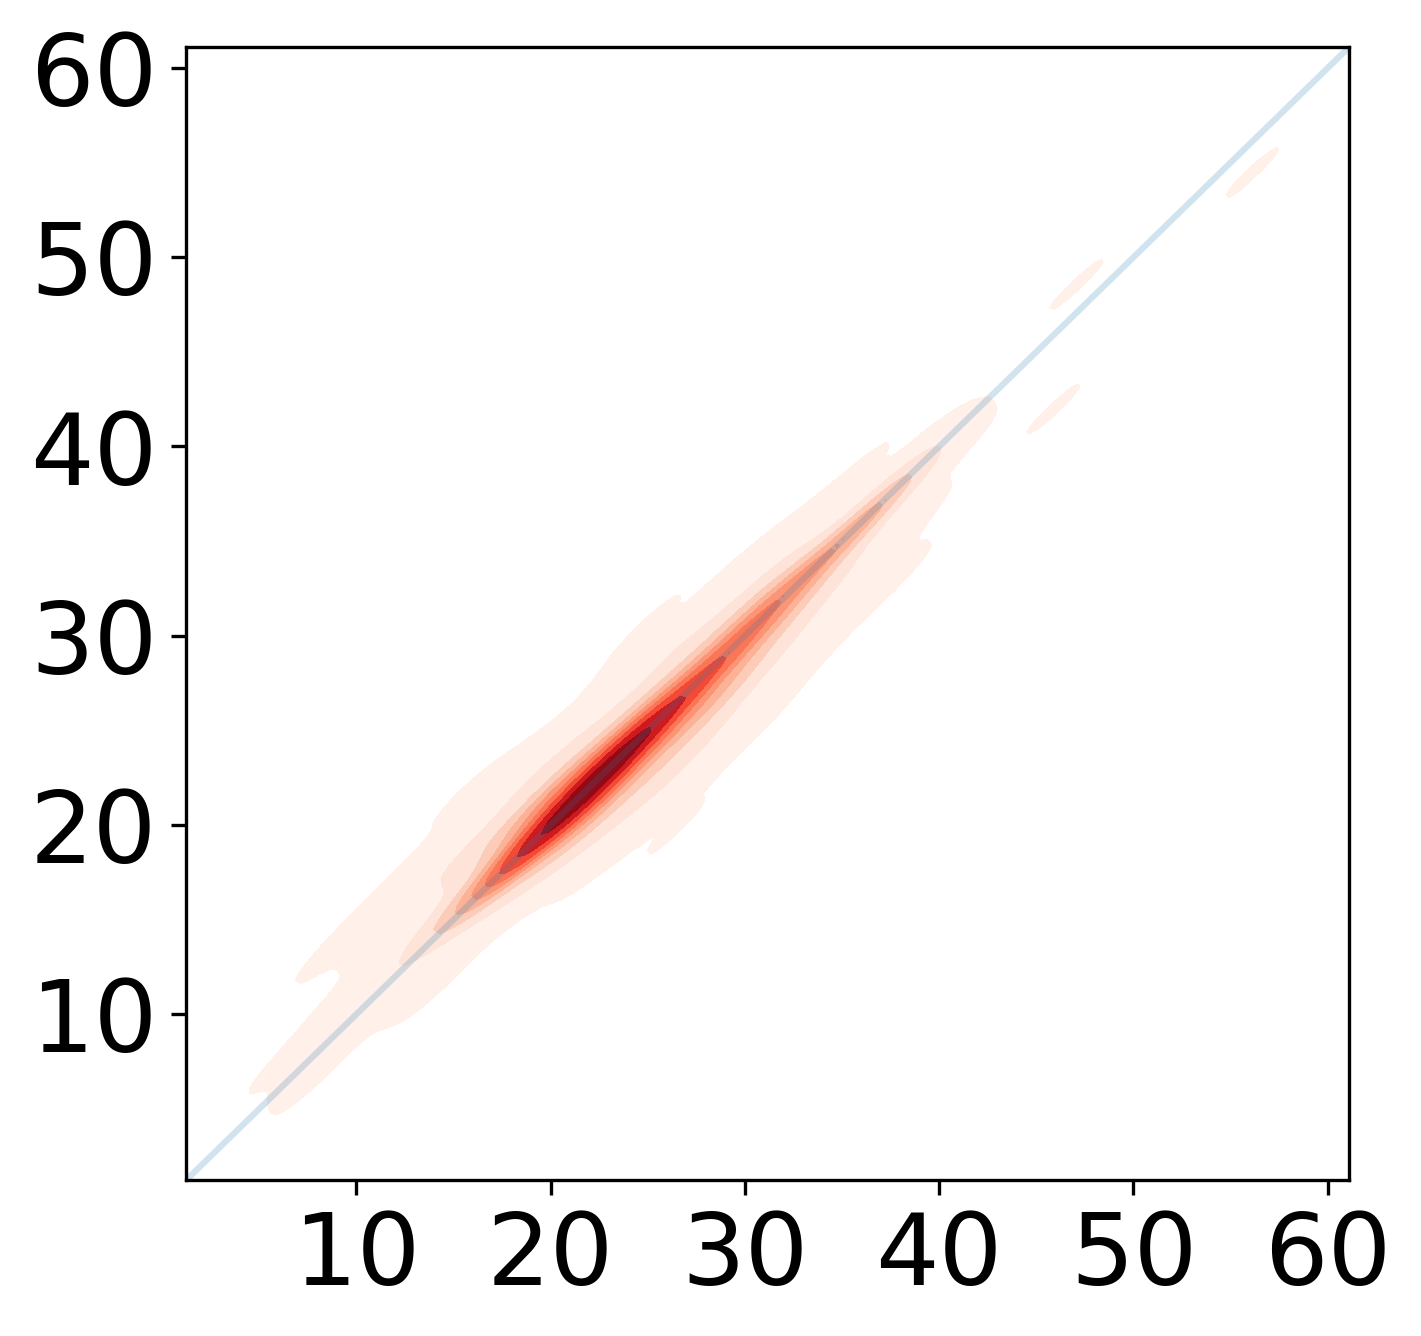

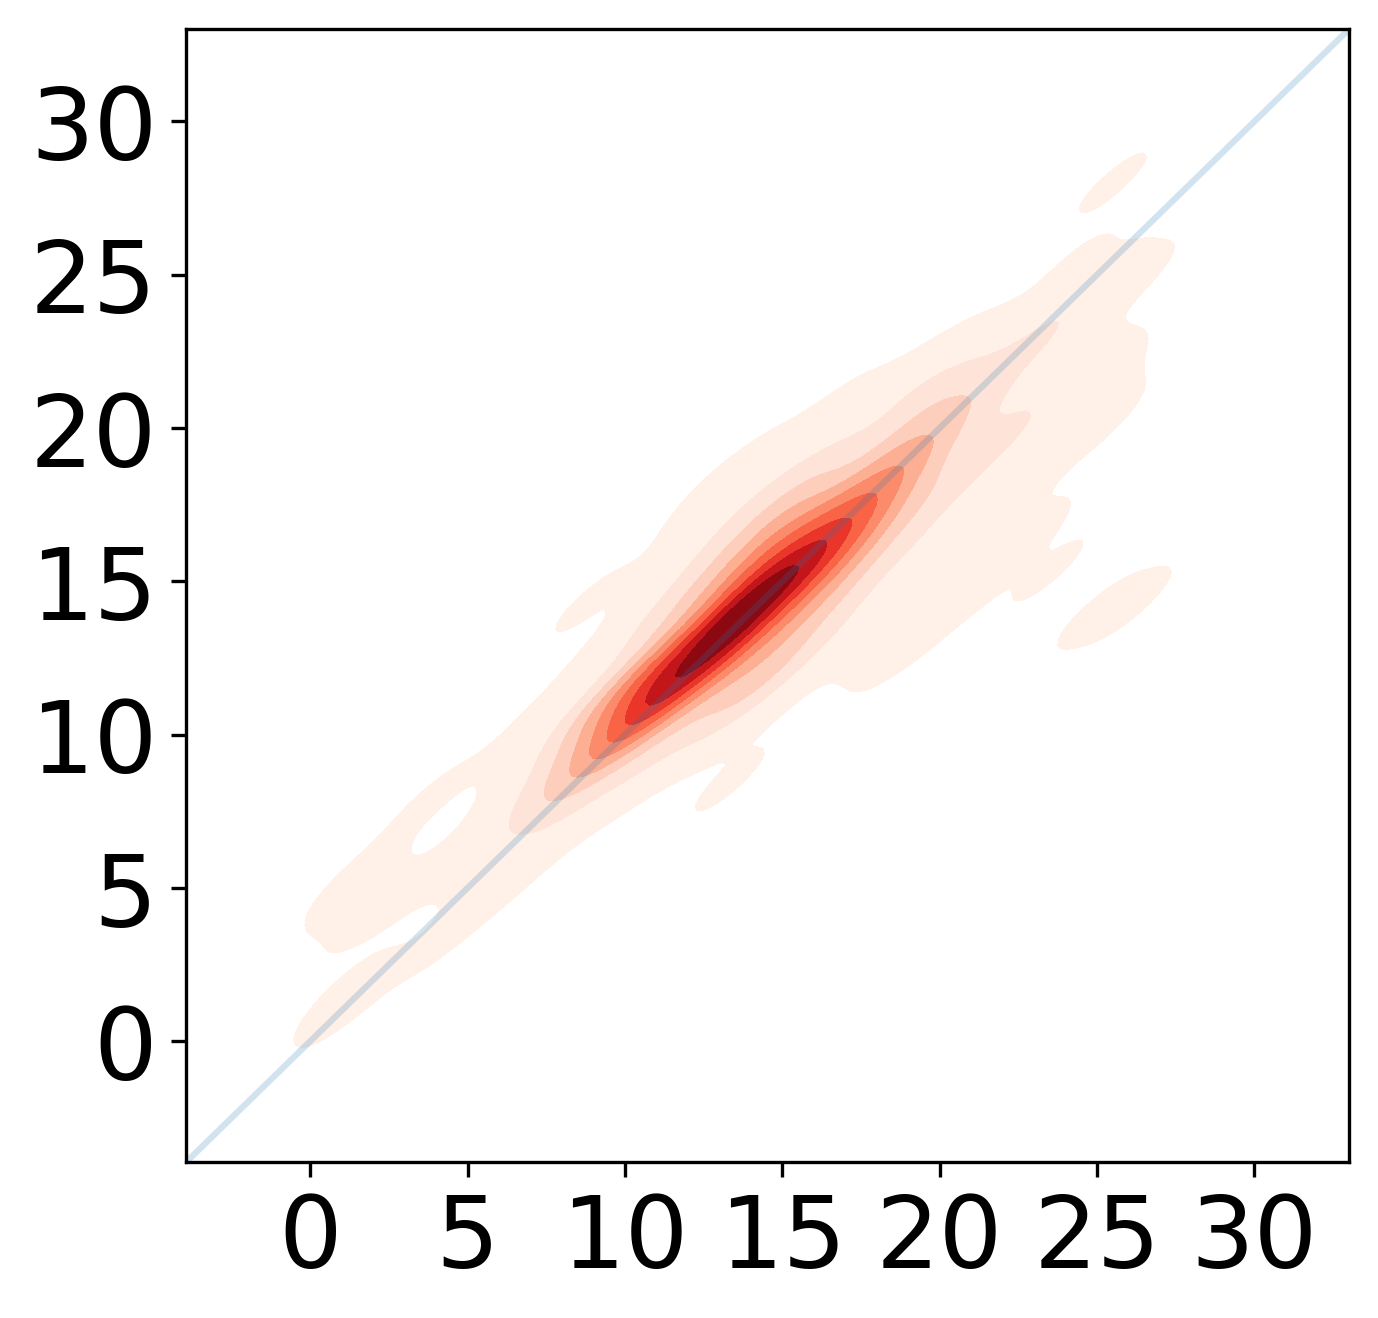

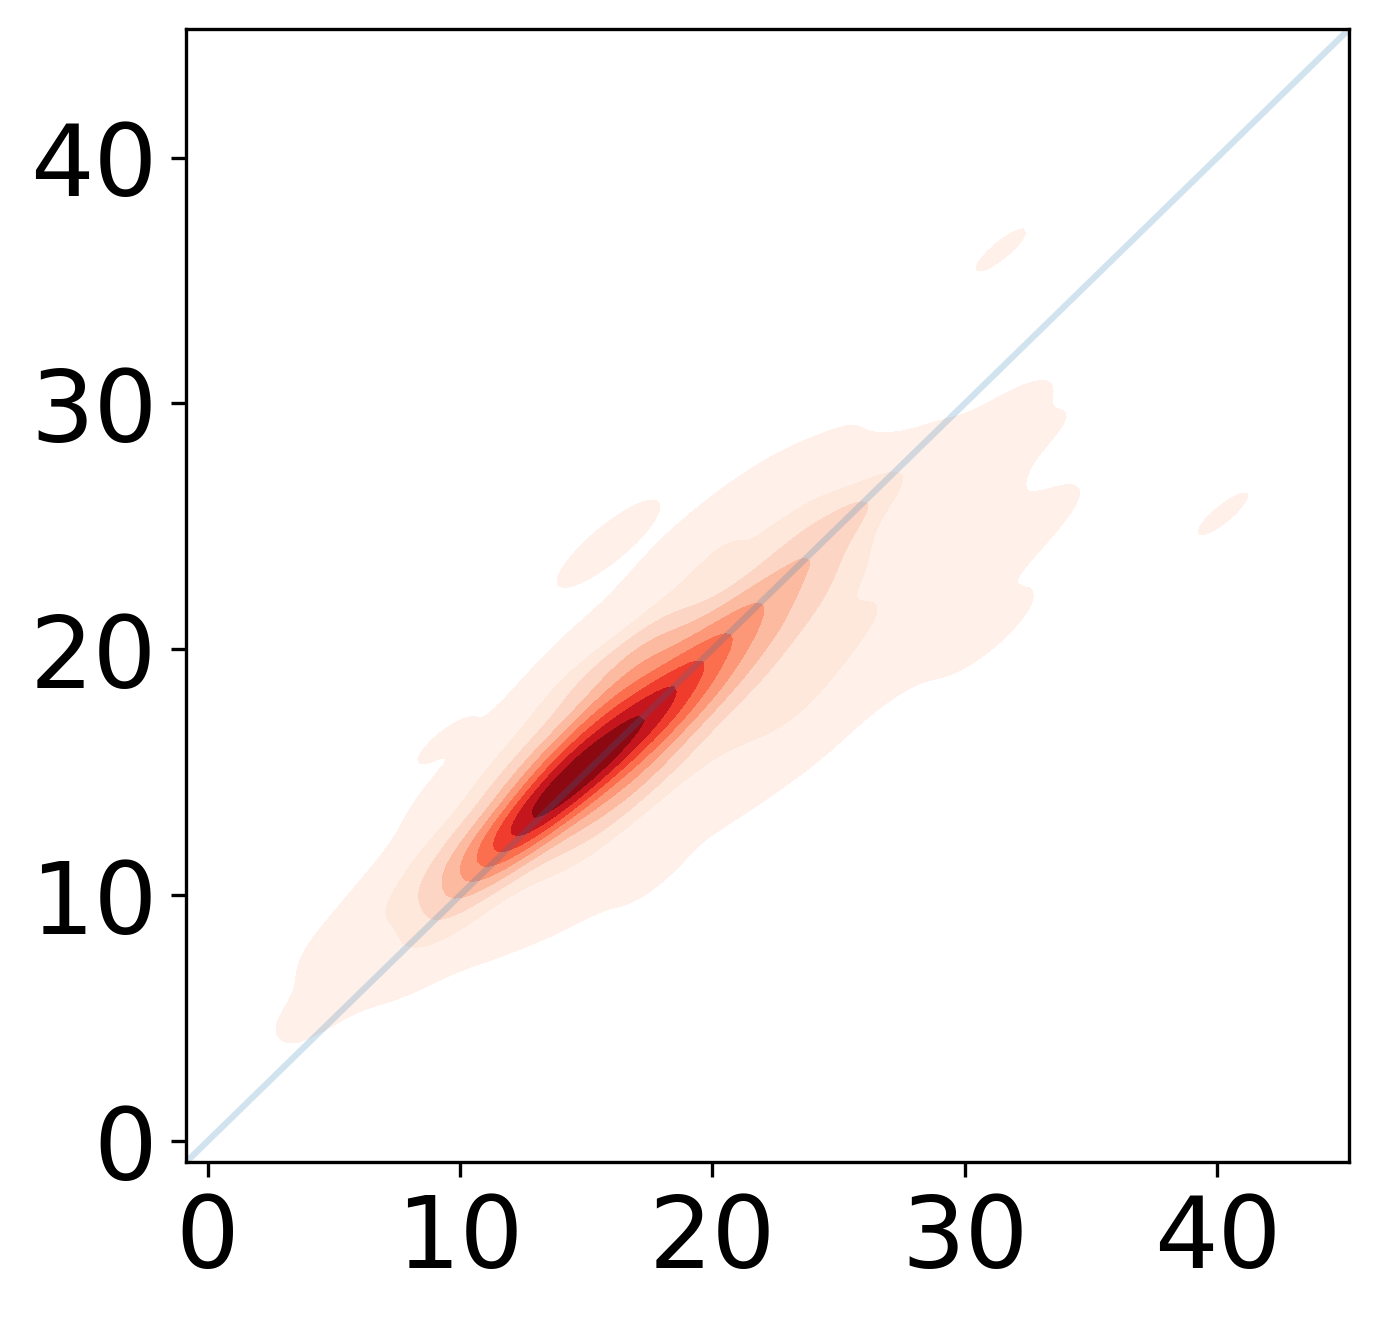

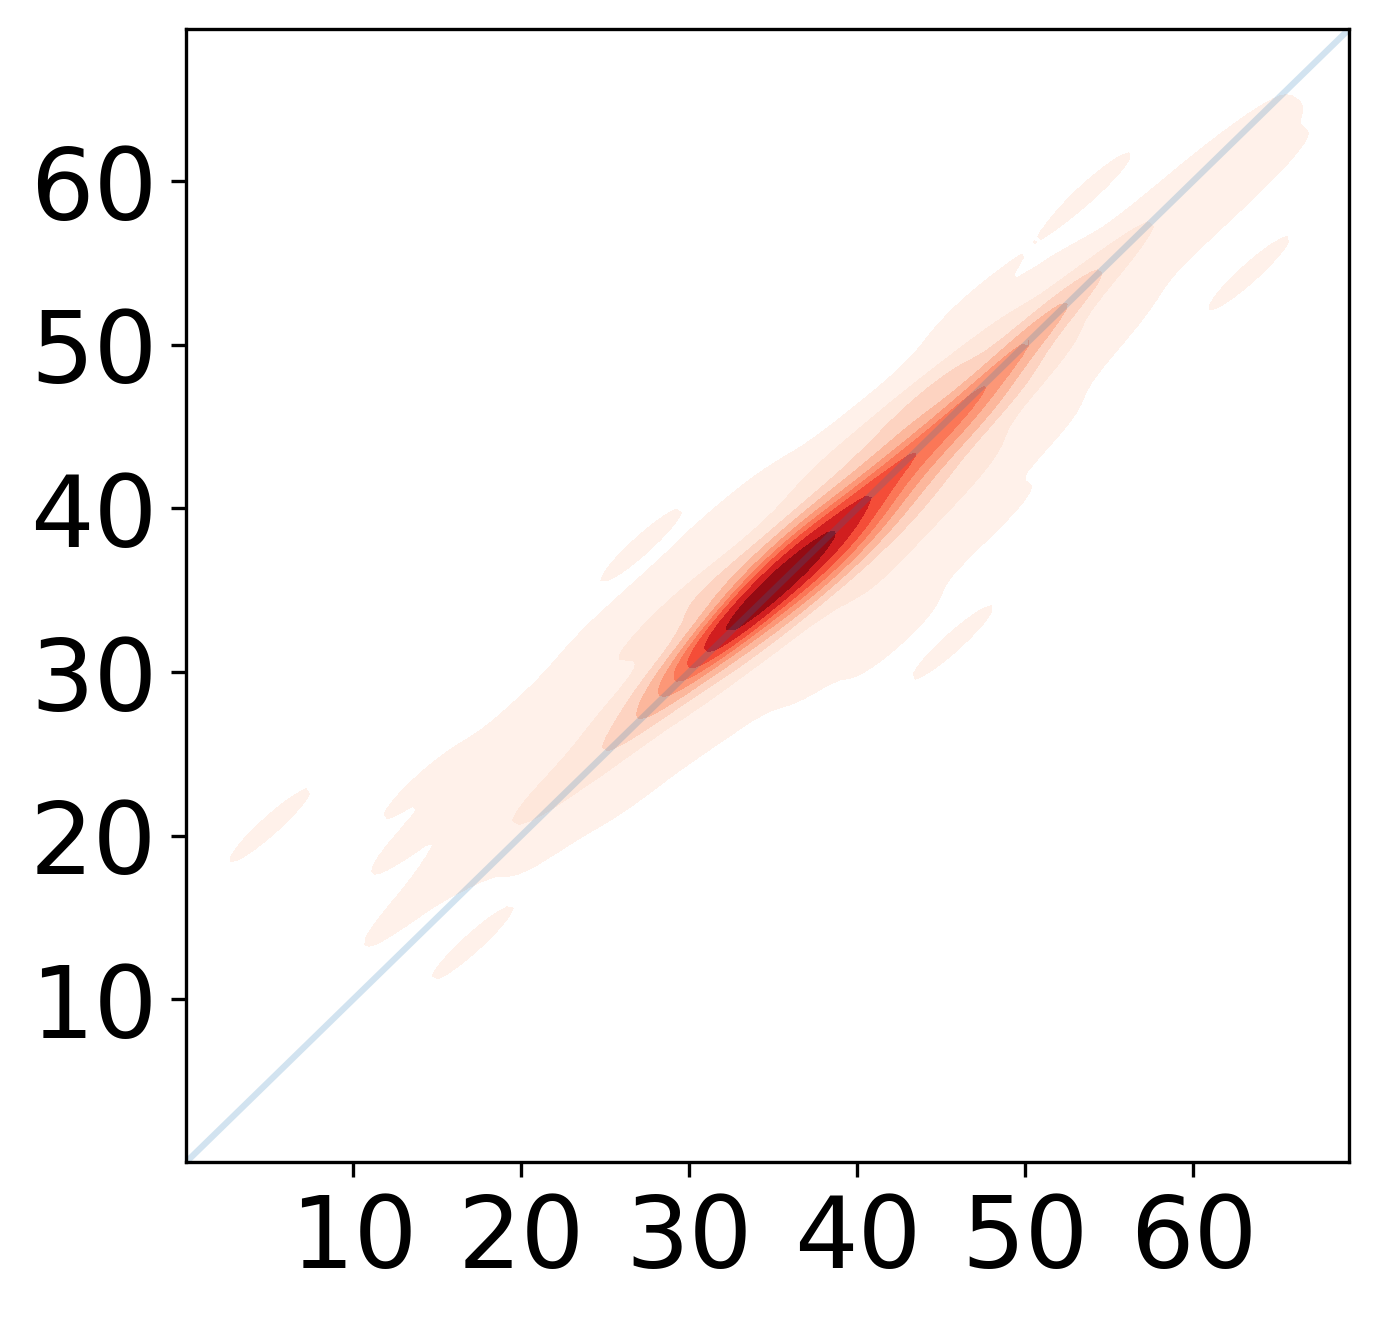

In [43]:
for save_name, test_true, test_pred in zip(['AttFP_Result/ourmodel_4pd', 'AttFP_Result/ourmodel_2pd', 'AttFP_Result/ourmodel_Int', 'AttFP_Result/ourmodel_dGa'], all_test_trues, all_test_preds):
    model_train.plot_scatter_with_metrics(test_true, test_pred, alpha=0.01, savename=save_name)

In [30]:
p_dropout = 0.1
fingerprint_dim = 512
weight_decay = 5.0  # also known as l2_regularization_lambda
learning_rate = 4.0
radius = 2
T = 2
batch_size = 128
epochs = 400
with_X = False
x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(
    [canonical_smiles_list[8]], feature_dicts)
num_atom_features = x_atom.shape[-1]
num_bond_features = x_bonds.shape[-1]

loss_function = nn.MSELoss()
if with_X:
    concat_dim = X_train.shape[-1]
    model = Fingerprint_conc(radius, T, num_atom_features, num_bond_features,
                    fingerprint_dim, concat_dim, output_units_num, p_dropout)
else:
    model = Fingerprint(radius, T, num_atom_features, num_bond_features,
                    fingerprint_dim, output_units_num, p_dropout)

model.cuda()
optimizer = optim.Adam(model.parameters(), 10 ** -learning_rate, weight_decay=10 ** -weight_decay)


model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])

best_param = {}
best_param["train_epoch"] = 0
best_param["valid_epoch"] = 0
best_param["train_MSE_normalized"] = 9e8
best_param["valid_MSE_normalized"] = 9e8
for epoch in range(epochs):
    if with_X:
        train(model, train_df, optimizer, loss_function, X_train)
        train_MAE_normalized, train_MAE, train_MSE_normalized, train_MSE, train_r2 = eval(model, train_df, X_train)
        valid_MAE_normalized, valid_MAE, valid_MSE_normalized, valid_MSE, valid_r2 = eval(model, valid_df, X_valid)
        _, valid_MAE, _, test_MSE, test_r2 = eval(model, test_df, X_test)
    else:
        train(model, train_df, optimizer, loss_function)
        train_MAE_normalized, train_MAE, train_MSE_normalized, train_MSE, train_r2 = eval(model, train_df)
        valid_MAE_normalized, valid_MAE, valid_MSE_normalized, valid_MSE, valid_r2 = eval(model, valid_df)
        _, valid_MAE, _, test_MSE, test_r2 = eval(model, test_df)
    print("EPOCH:\t" + str(epoch) + '\n' \
          #         +"train_MAE_normalized: "+str(train_MAE_normalized)+'\n'\
          #         +"valid_MAE_normalized: "+str(valid_MAE_normalized)+'\n'\
          + "train_R2" + ":"  + str(train_r2) + '\n' \
          + "valid_R2" + ":"  + str(valid_r2) + '\n' \
          + "test_R2" + ":"  + str(test_r2) + '\n' \
          + "train_MAE" + ":"  + str(train_MAE) + '\n' \
          + "valid_MAE" + ":"  + str(valid_MAE) + '\n' \
\
        #   + "train_MSE_normalized_mean: " + str(train_MSE_normalized.mean()) + '\n' \
        #   + "valid_MSE_normalized_mean: " + str(valid_MSE_normalized.mean()) + '\n' \
          #         +"train_MSE_normalized: "+str(train_MSE_normalized)+'\n'\
          #         +"valid_MSE_normalized: "+str(valid_MSE_normalized)+'\n'\
          )
    if train_MSE_normalized.mean() < best_param["train_MSE_normalized"]:
        best_param["train_epoch"] = epoch
        best_param["train_MSE_normalized"] = train_MSE_normalized.mean()
    if valid_MSE_normalized.mean() < best_param["valid_MSE_normalized"]:
        best_param["valid_epoch"] = epoch
        best_param["valid_MSE_normalized"] = valid_MSE_normalized.mean()
        if valid_MSE_normalized.mean() < 0.4:
            torch.save(model, 'AttFP_Model/model' + '_' + str(epoch) + '.pt')

    # if (epoch - best_param["train_epoch"] > 10) and (epoch - best_param["valid_epoch"] > 18):
    #     break

print('ENDE')

EPOCH:	0
train_R2:[0.2554996386522289, 0.08598924264491825, 0.17098038973343022, 0.2297713822523526]
valid_R2:[0.2753952627724887, 0.0745185450235708, 0.16751804374513402, 0.24866589756017288]
test_R2:[0.25549100712763817, 0.06265650538428913, 0.19998188013526996, 0.23605526016032963]
train_MAE:[4.10536794 2.8240239  3.28616637 5.26316572]
valid_MAE:[4.06754933 2.76863135 3.18290431 5.08958333]

EPOCH:	1
train_R2:[0.35264250909722117, 0.09797385139806514, 0.21664215921581287, 0.30894036247752454]
valid_R2:[0.36147248755732064, 0.07541689053374612, 0.21107843180009678, 0.30798910106094624]
test_R2:[0.334609708623265, 0.05481249378747166, 0.24562808114567147, 0.29700040841622166]
train_MAE:[3.76663553 2.81841978 3.18902835 4.93098658]
valid_MAE:[3.75512076 2.80695171 3.08681346 4.81089212]

EPOCH:	2
train_R2:[0.3903671583683971, 0.14594463095538557, 0.2578298763295581, 0.3441142964379843]
valid_R2:[0.38906719879483354, 0.12628133720934198, 0.25687464482755795, 0.33060919669666344]
test_R

In [51]:
model = torch.load("AttFP_Model\model_264.pt")
y_val_lists, y_pred_lists = eval(model, test_df, X=[], return_value=True)
for task, y_val_list, y_pred_list in zip(tasks, y_val_lists, y_pred_lists):
    r2, mae, mse = r2_score(y_val_list, y_pred_list), mean_absolute_error(y_val_list, y_pred_list), mean_squared_error(y_val_list, y_pred_list)
    print(f"task:{task}, Test_R2:{r2:.4f} Test_MAE:{mae: .4f} Test_MSE:{mse: .4f}")

task:Diene_Distort, Test_R2:0.8946 Test_MAE: 1.4477 Test_MSE: 3.8598
task:Ene_Distort, Test_R2:0.6737 Test_MAE: 1.5055 Test_MSE: 4.7075
task:Interaction, Test_R2:0.7276 Test_MAE: 1.7810 Test_MSE: 6.0478
task:deltaGa(Solvent), Test_R2:0.8355 Test_MAE: 2.1777 Test_MSE: 9.9130


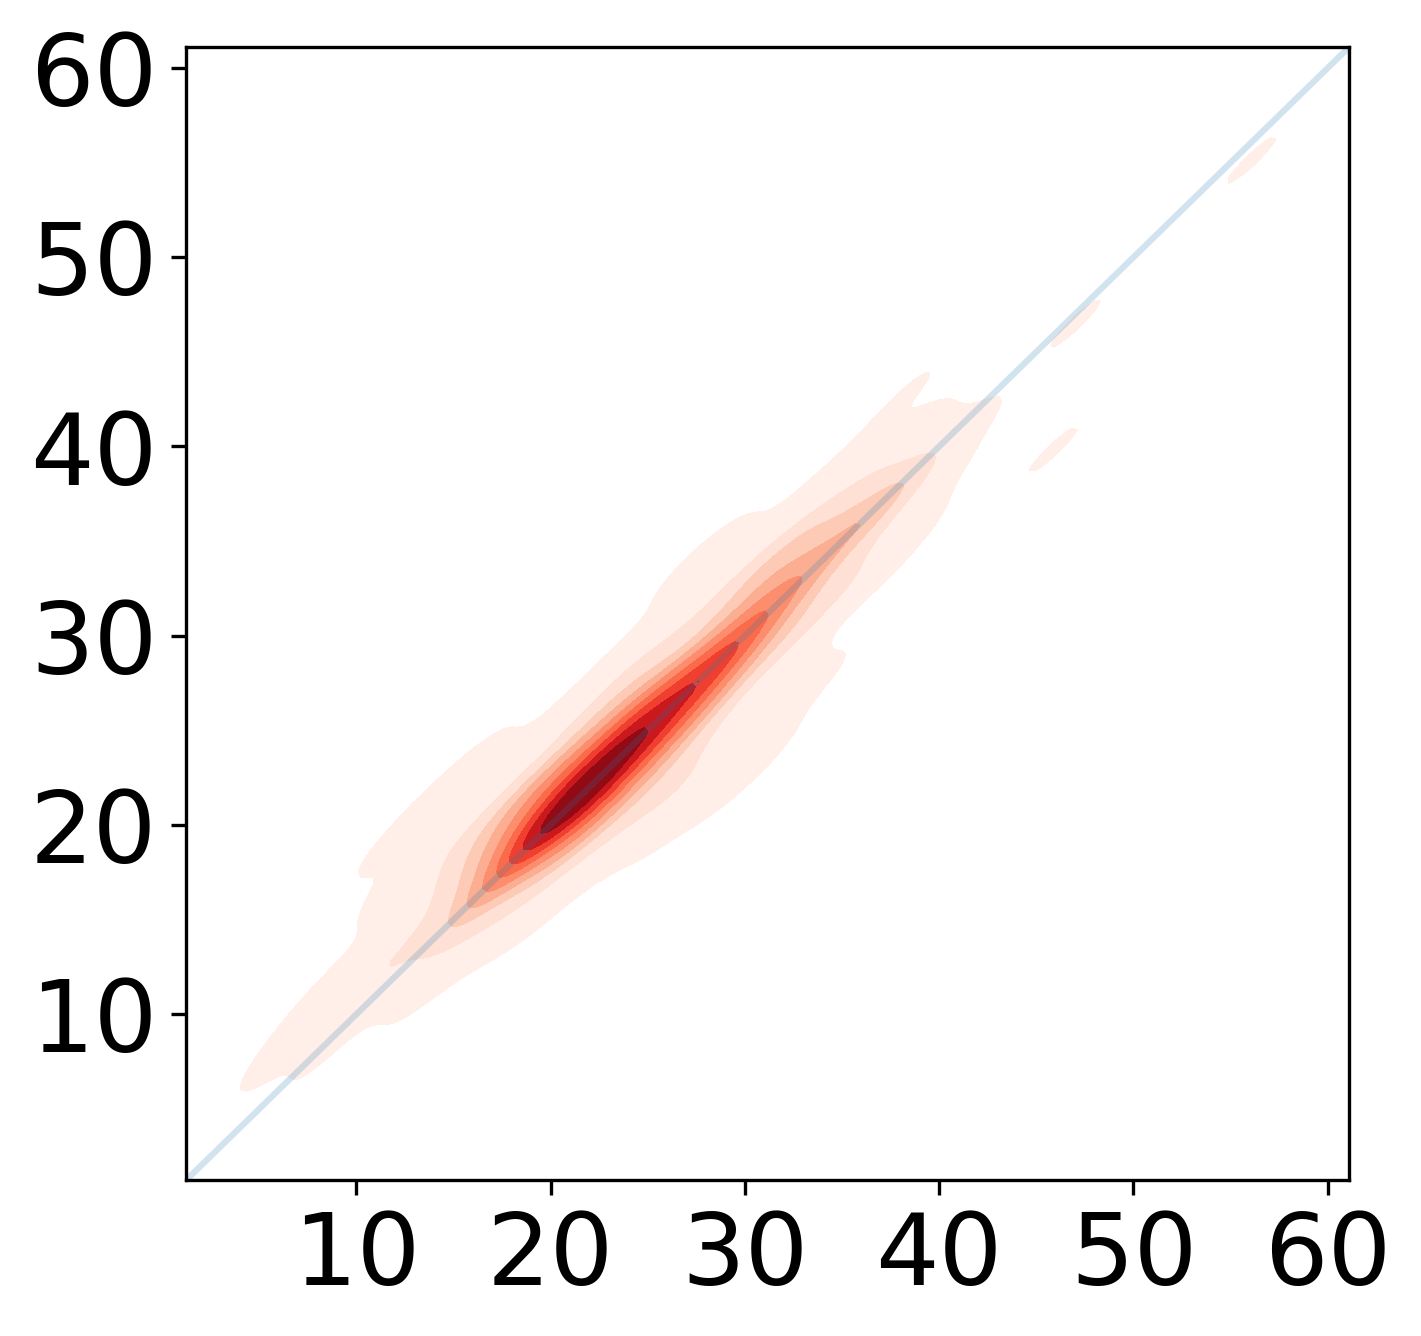

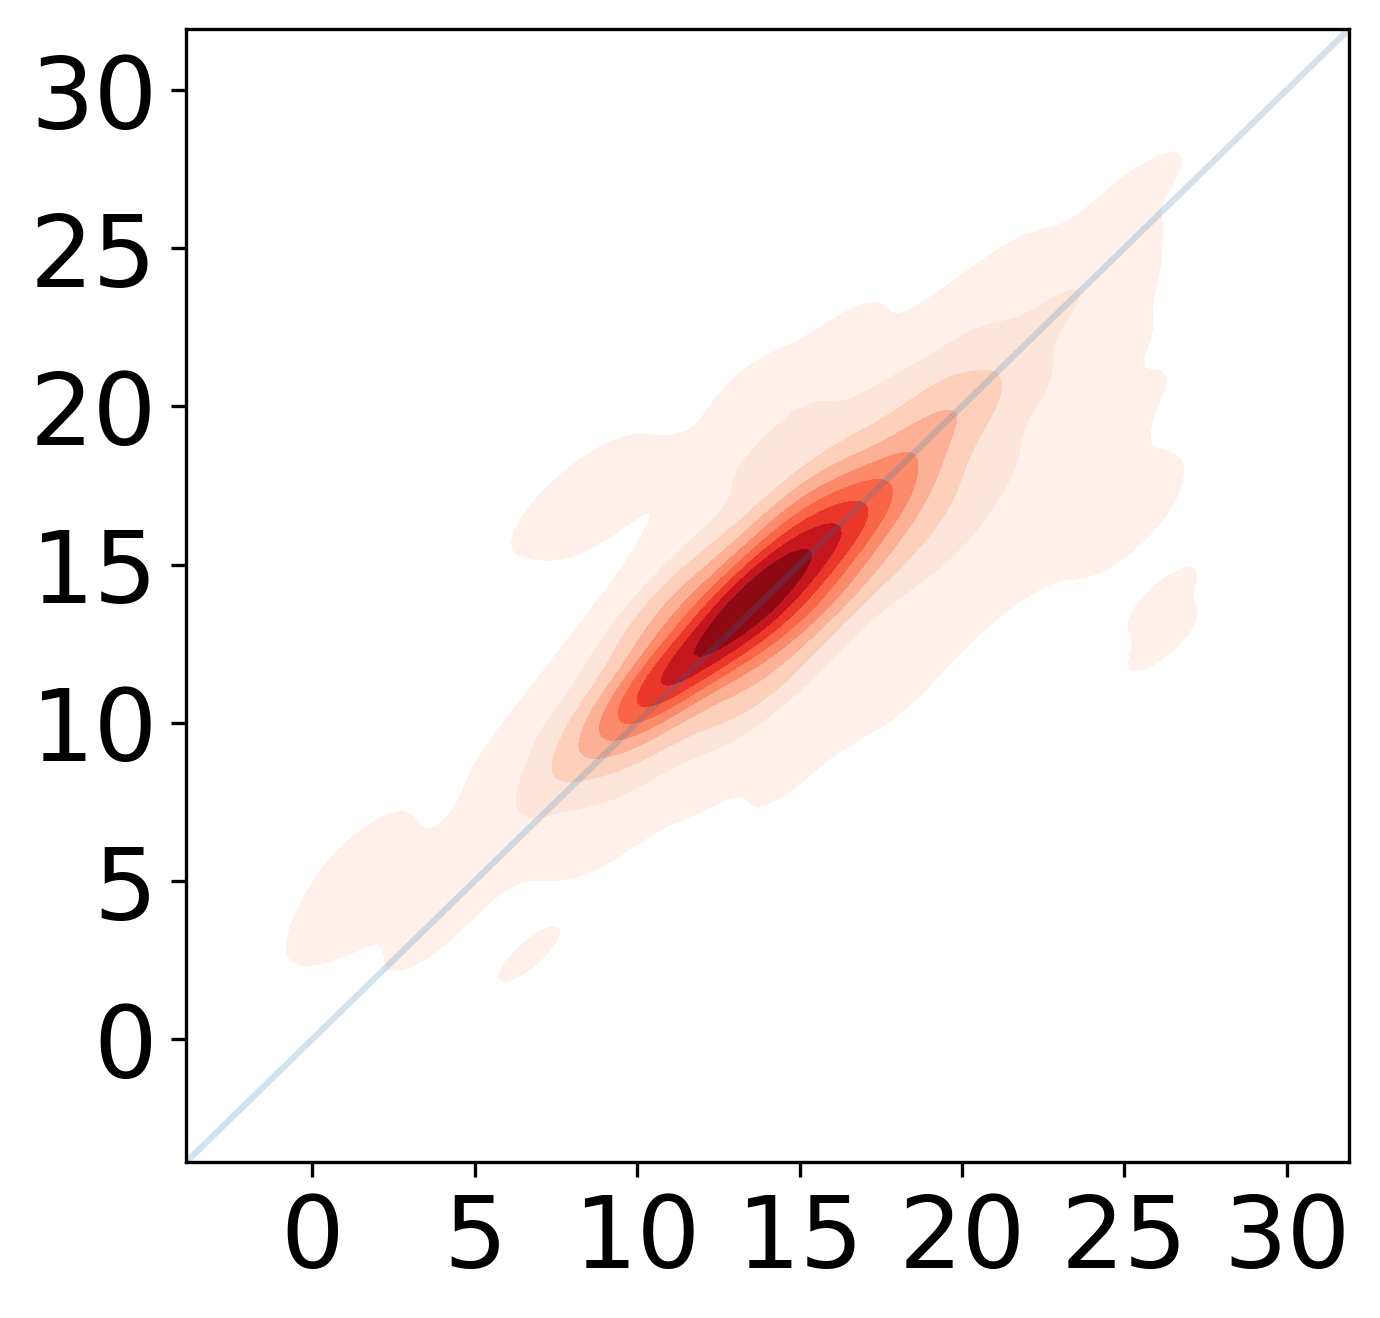

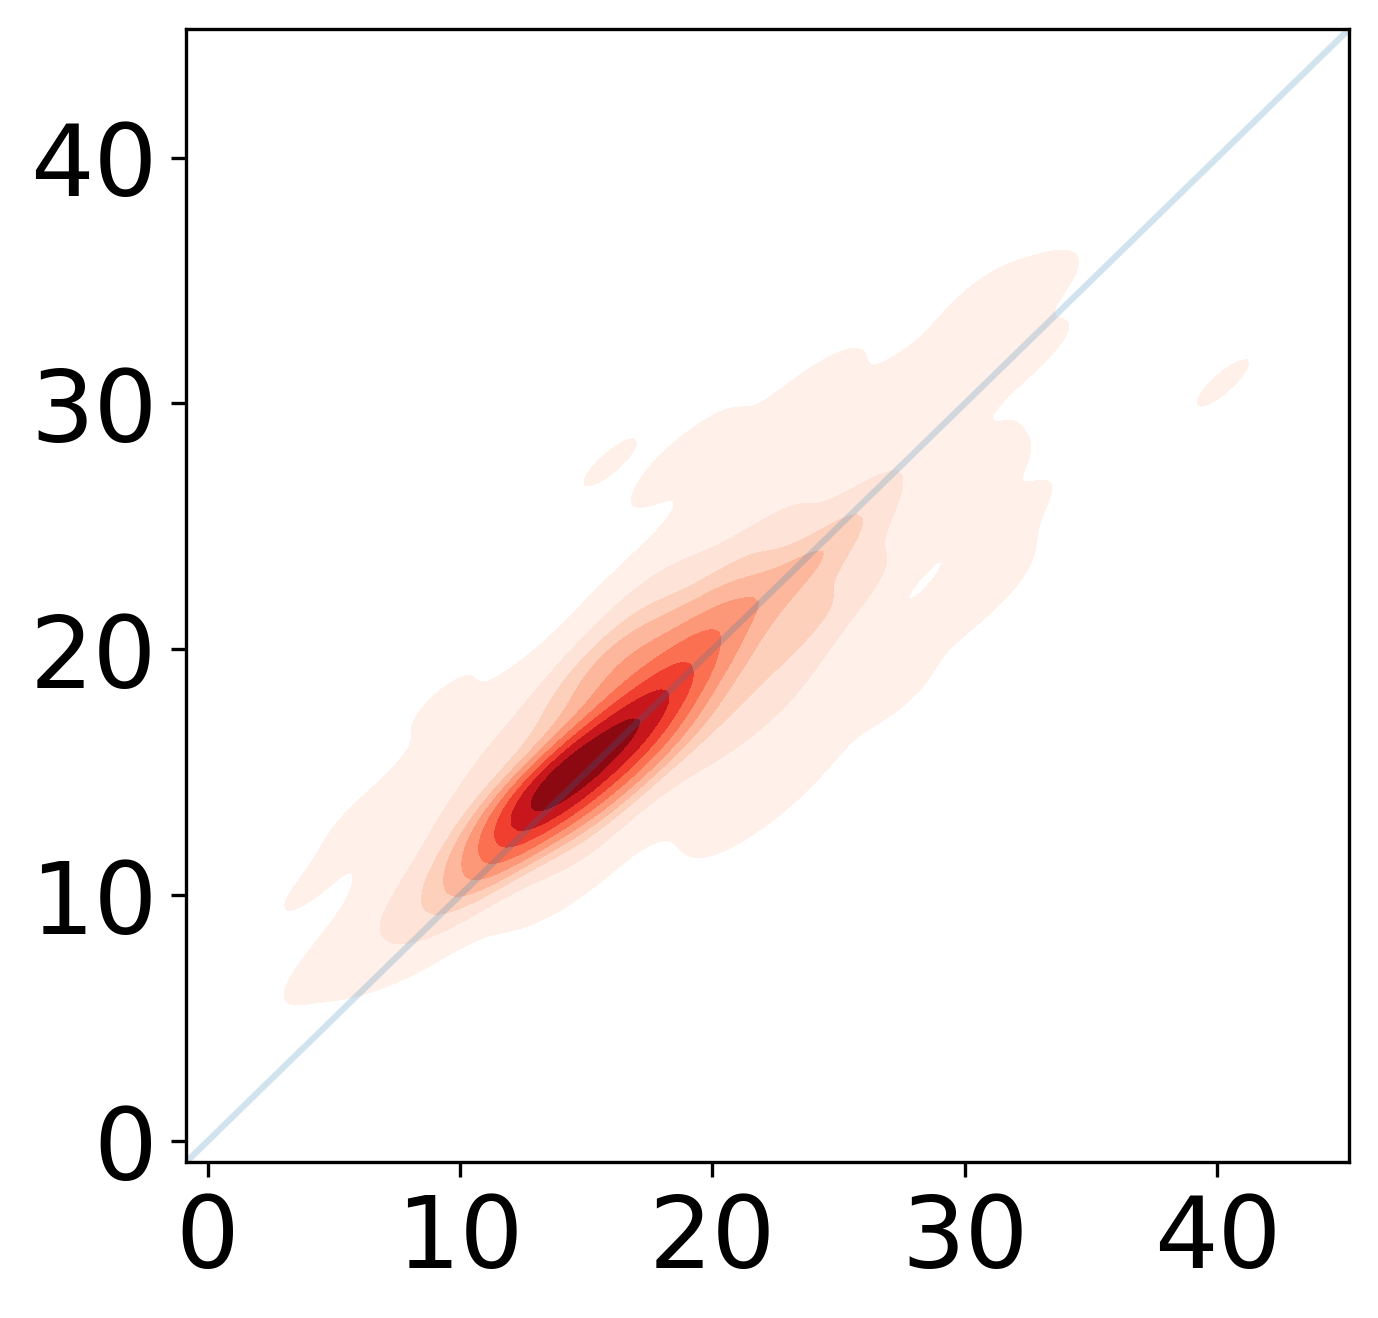

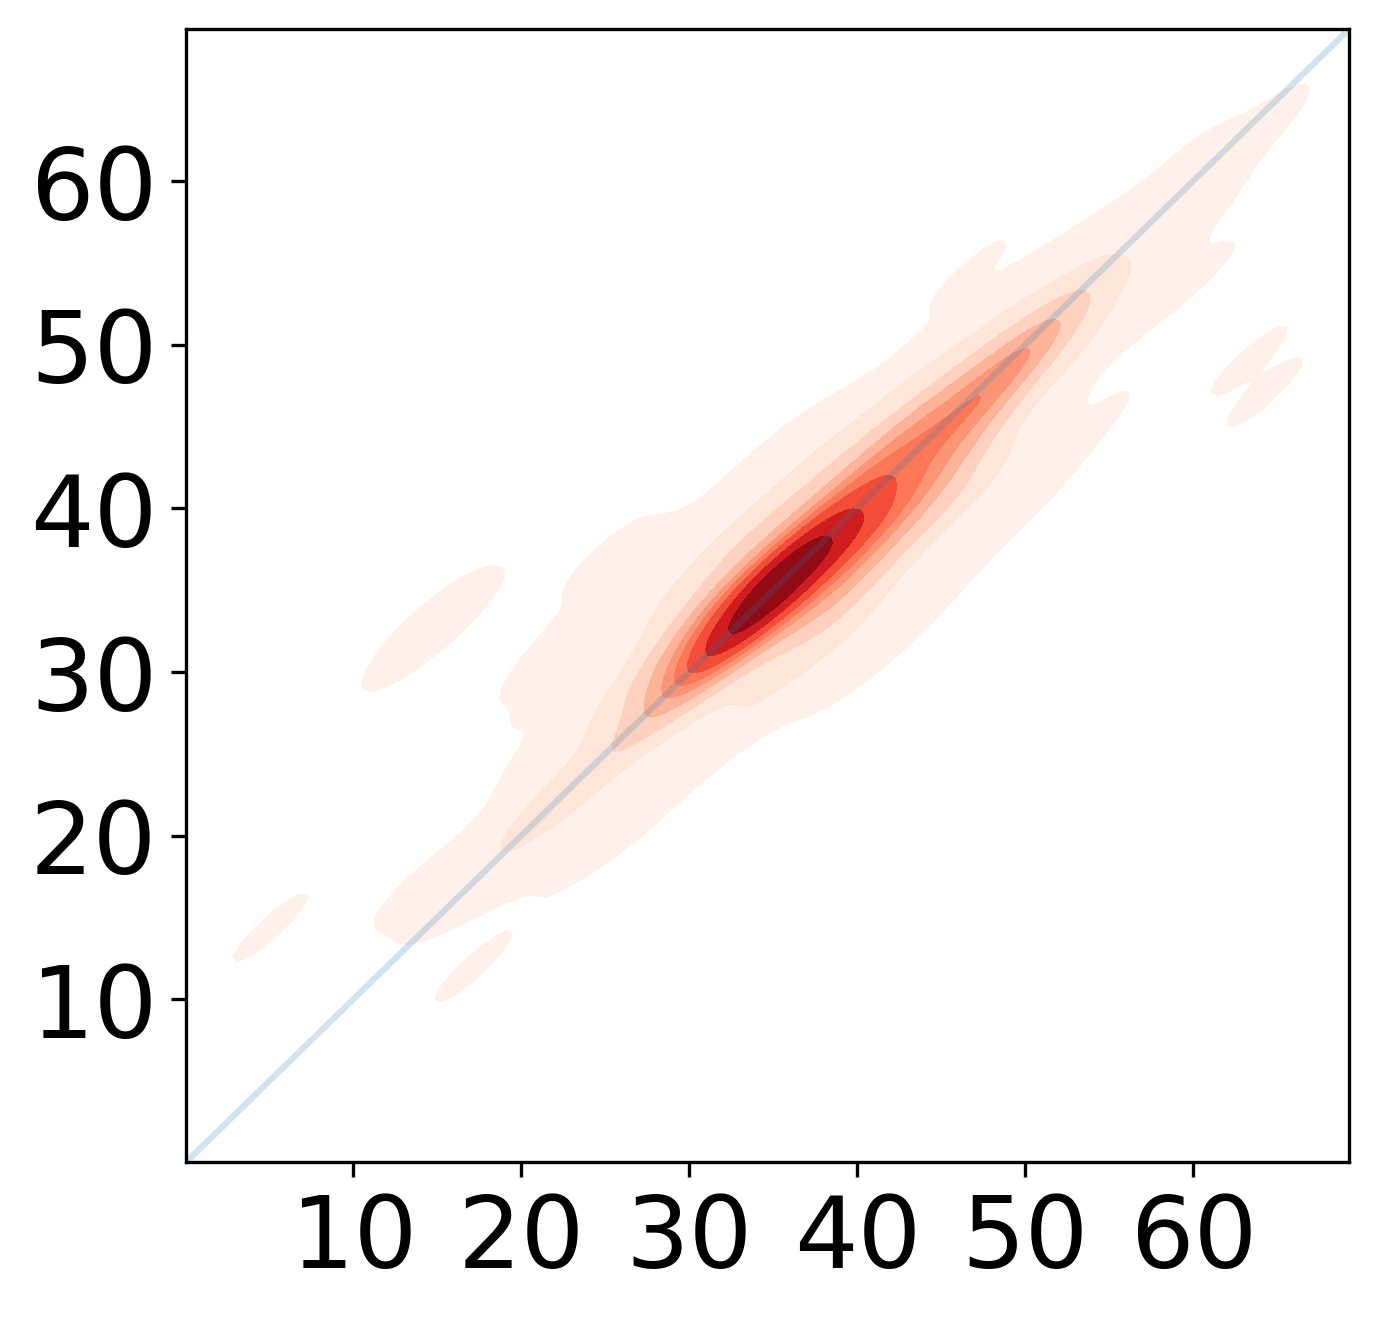

In [52]:
for save_name, test_true, test_pred in zip(['AttFP_Result/AttFP_4pd', 'AttFP_Result/AttFP_2pd', 'AttFP_Result/AttFP_Int', 'AttFP_Result/AttFP_dGa'], y_val_lists, y_pred_lists):
    model_train.plot_scatter_with_metrics(test_true, test_pred, alpha=0.01, savename=save_name)

In [37]:
r2_1 = r2_score(test_df['deltaEa'], dd_test + ed_test - in_test)
r2_2 = r2_score(dd_real + ed_real - in_real, dd_pred + ed_pred - in_pred)
print(r2_1, r2_2)

0.9082428334239705 0.27676714726470586


In [ ]:
# AttFP VS CatBoost
# dE Vs 
# dd 0.920 Vs 0.938
# ed 0.712 Vs 0.796
# in 0.725 Vs 0.788

In [ ]:
# AttFP VS CatBoost (Best in reactions)
# dE Vs 0.780
# dd 0.920 Vs 0.938
# ed 0.712 Vs 0.796
# in 0.725 Vs 0.788

In [56]:
from matplotlib import pyplot as plt
plt.scatter(dd_real + ed_real - in_real, dd_test + ed_test - in_test)
plt.savefig('test1.svg', format='svg', dpi=1200)

DD
EPOCH:	138
train_R2:0.9635595023903698
valid_R2:0.9099426192719446
test_R2:0.9199360227652361
train_MAE:[0.87621506]
valid_MAE:[1.2670481]

ED
EPOCH:	157
train_R2:0.8937445973273642
valid_R2:0.7828775660641676
test_R2:0.7124524008154691
train_MAE:[0.90831995]
valid_MAE:[1.43557448]

IN
EPOCH:	131
train_R2:0.86031269642976
valid_R2:0.7415819059155995
test_R2:0.7252069462420868
train_MAE:[1.30499664]
valid_MAE:[1.84892091]

# 产生用于WLN的csv

In [53]:
from cycle_process import diene_atom_Idx

In [55]:
target_csv = pd.read_csv("../Data/Iteration_Data/Active_Energy.csv")
new_dict = {"rxn_id":{}, "smiles":{}, "DD":{}, "ED":{}, "IN":{}, "DG_TS":{}, "G_r":{}}
new_dict_id = 0
for row_id, row in target_csv.iterrows():
    diene = Chem.MolFromMolFile(rf"G:\work\Secondary_Selection\Diene_Ene_Smiles\mol\smilesid_{row['Diene_Index']:05}.mol", removeHs=True)
    Chem.Kekulize(diene, clearAromaticFlags=True)
    [atom.SetAtomMapNum(each + 1) for each, atom in enumerate(diene.GetAtoms())]
    ene = Chem.MolFromMolFile(rf"G:\work\Secondary_Selection\Diene_Ene_Smiles\mol\smilesid_{row['Ene_Index']:05}.mol", removeHs=True)
    [atom.SetAtomMapNum(each + 1 + diene.GetNumAtoms()) for each, atom in enumerate(ene.GetAtoms())]
    Chem.Kekulize(ene, clearAromaticFlags=True)
    title = [int(each) for each in row['Title'].split()]
    title[4] = diene.GetNumAtoms()
    react_sites = diene.GetSubstructMatches(Chem.MolFromSmarts("*=**=*"))
    react_site = None
    diene_atom_lists = diene_atom_Idx(diene, select_diene=0)
    for each in diene_atom_lists:
        if each[0] == title[0] and each[-1] == title[1]:
            atomb_id, atomc_id = each[1:3]
            react_site = each
            break
    assert react_site != None
    product = Chem.CombineMols(diene, ene)
    rwmol = Chem.RWMol(product)
    rwmol.AddBond(react_site[0], title[2] + title[4], Chem.BondType.SINGLE)
    rwmol.AddBond(react_site[3], title[3] + title[4], Chem.BondType.SINGLE)
    another_bond1 = rwmol.GetBondBetweenAtoms(react_site[0], react_site[1])
    another_bond2 = rwmol.GetBondBetweenAtoms(react_site[2], react_site[3])
    another_bond1.SetBondType(Chem.BondType.SINGLE)
    another_bond2.SetBondType(Chem.BondType.SINGLE)
    bond3 = rwmol.GetBondBetweenAtoms(react_site[1], react_site[2])
    bond3.SetBondType(Chem.BondType.DOUBLE)
    bond4 = rwmol.GetBondBetweenAtoms(title[2] + title[4], title[3] + title[4])
    if bond4.GetBondType() == Chem.BondType.DOUBLE:
        bond4.SetBondType(Chem.BondType.SINGLE)
    elif bond4.GetBondType() == Chem.BondType.TRIPLE:
        bond4.SetBondType(Chem.BondType.DOUBLE)
    Chem.SanitizeMol(rwmol)
    product = rwmol.GetMol()
    target_smiles = Chem.MolToSmiles(diene) + "." + Chem.MolToSmiles(ene) + ">>" + Chem.MolToSmiles(product)
    new_dict["rxn_id"][new_dict_id] = new_dict_id
    new_dict["smiles"][new_dict_id] = target_smiles
    new_dict["DD"][new_dict_id] = row["Diene_Distort"]
    new_dict["ED"][new_dict_id] = row["Ene_Distort"]
    new_dict["IN"][new_dict_id] = row["Interaction"]
    new_dict["DG_TS"][new_dict_id] = row["deltaGa(Solvent)"]
    new_dict['G_r'][new_dict_id] = row["deltaG"]
    new_dict_id += 1
new_dict = pd.DataFrame(new_dict)
new_dict.to_csv("multitask_QM_GNN-develop/datasets/Activate_Energy.csv")

[17:53:24] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:24] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:24] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:24] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:24] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:24] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:25] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:25] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:25] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:26] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:26] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:26] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:26] Warning: molecule is tagged as 3D, but all Z coords are zero
[17:53:26] Warning: molecule is tagged as 3D, but all Z coords a

In [14]:
X, _, _ = Bayesian_Optimization.descriptor_generator([target_csv], _, 0, 1, 0, 1, "Interaction", r"G:\work\Secondary_Selection\Diene_Ene_Smiles\all_property_detailSterimol.pkl", is_3d_map=0, calc_area=1, calc_bv=0, calc_HB=0)
row_ids = np.arange(len(target_csv))
target_dict = {'rxn_id':row_ids, "smiles":new_dict['smiles']}
for id_, each in enumerate(X.T):
    target_dict[id_] = each
target_dict = pd.DataFrame(target_dict)

100%|██████████| 2304/2304 [00:27<00:00, 84.00it/s]


In [15]:
target_dict.to_csv("multitask_QM_GNN-develop/descriptors/ZINC1234_clear_reaction_des.csv")